# Consumer Complaint Classification using DistilBERT

## 1. Install Libraries


In [ ]:
!pip -q install transformers datasets accelerate evaluate



## 2. Import Libraries

In [3]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

import torch

from datasets import Dataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)

In [4]:
print("=" * 50)

print("PyTorch Version :", torch.__version__)

print("CUDA Available :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

print("=" * 50)

PyTorch Version : 2.10.0+cu128
CUDA Available : True
GPU : Tesla T4


## 3. Load Dataset

In [5]:
df = pd.read_csv(
    "/kaggle/input/datasets/mohamedafifi77/cleaned-data/cleaned_complaints.csv"
)

print("Dataset Shape :", df.shape)

df.head()

Dataset Shape : (162411, 2)


,product,narrative
0,credit_card,purchase order day shipping amount receive pro...
1,credit_card,forwarded message date tue subject please inve...
2,retail_banking,forwarded message cc sent friday pdt subject f...
3,credit_reporting,payment history missing credit report speciali...
4,credit_reporting,payment history missing credit report made mis...


## 4. Prepare Labels


In [7]:
label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["product"])

print(label_encoder.classes_)

['credit_card' 'credit_reporting' 'debt_collection' 'mortgages_and_loans'
 'retail_banking']


In [8]:
NUM_CLASSES = len(label_encoder.classes_)

print("Number of Classes :", NUM_CLASSES)

df.head()

Number of Classes : 5


,product,narrative,label
0,credit_card,purchase order day shipping amount receive pro...,0
1,credit_card,forwarded message date tue subject please inve...,0
2,retail_banking,forwarded message cc sent friday pdt subject f...,4
3,credit_reporting,payment history missing credit report speciali...,1
4,credit_reporting,payment history missing credit report made mis...,1


In [9]:
with open("/kaggle/working/bert_label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("Label Encoder Saved Successfully")

Label Encoder Saved Successfully


## 5. Train-Test Split

In [10]:
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

In [11]:
train_df = train_df.reset_index(drop=True)

test_df = test_df.reset_index(drop=True)

print("Train Shape :", train_df.shape)

print("Test Shape :", test_df.shape)

Train Shape : (129928, 3)
Test Shape : (32483, 3)


## 6. Tokenization

In [12]:
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [13]:
MAX_LENGTH = 256
def tokenize_function(example):
    return tokenizer(
        example["narrative"],
        truncation=True,
        max_length=MAX_LENGTH
    )

## 7. Build HuggingFace Dataset

In [14]:
train_dataset = Dataset.from_pandas(
    train_df[["narrative", "label"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[["narrative", "label"]],
    preserve_index=False
)

In [15]:
train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/129928 [00:00<?, ? examples/s]

Map:   0%|          | 0/32483 [00:00<?, ? examples/s]

In [18]:
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

In [19]:
print(train_dataset)

print(test_dataset)

Dataset({
    features: ['narrative', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 129928
})
Dataset({
    features: ['narrative', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 32483
})


## 8. Build DistilBERT Model

In [21]:
NUM_CLASSES = len(label_encoder.classes_)

print("Number of Classes:", NUM_CLASSES)

Number of Classes: 5


In [22]:
id2label = {
    i: label
    for i, label in enumerate(label_encoder.classes_)
}

label2id = {
    label: i
    for i, label in enumerate(label_encoder.classes_)
}

In [23]:
MODEL_NAME = "distilbert-base-uncased"

In [24]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    id2label=id2label,
    label2id=label2id
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [25]:
print(model.config)

DistilBertConfig {
  "activation": "gelu",
  "architectures": [
    "DistilBertForMaskedLM"
  ],
  "attention_dropout": 0.1,
  "bos_token_id": null,
  "dim": 768,
  "dropout": 0.1,
  "dtype": "float32",
  "eos_token_id": null,
  "hidden_dim": 3072,
  "id2label": {
    "0": "credit_card",
    "1": "credit_reporting",
    "2": "debt_collection",
    "3": "mortgages_and_loans",
    "4": "retail_banking"
  },
  "initializer_range": 0.02,
  "label2id": {
    "credit_card": 0,
    "credit_reporting": 1,
    "debt_collection": 2,
    "mortgages_and_loans": 3,
    "retail_banking": 4
  },
  "max_position_embeddings": 512,
  "model_type": "distilbert",
  "n_heads": 12,
  "n_layers": 6,
  "pad_token_id": 0,
  "qa_dropout": 0.1,
  "seq_classif_dropout": 0.2,
  "sinusoidal_pos_embds": false,
  "tie_weights_": true,
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "vocab_size": 30522
}



In [26]:
print("Model Loaded Successfully!")

Model Loaded Successfully!


In [27]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

Total Parameters     : 66,957,317
Trainable Parameters : 66,957,317


## 9. Training Arguments

In [28]:
training_args = TrainingArguments(
    output_dir="/kaggle/working/distilbert_results",

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="accuracy",

    greater_is_better=True,

    save_total_limit=1,

    fp16=torch.cuda.is_available(),

    report_to="none",

    seed=42
)

In [29]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=1)

    accuracy = accuracy_score(labels, predictions)

    precision = precision_score(
        labels,
        predictions,
        average="macro"
    )

    recall = recall_score(
        labels,
        predictions,
        average="macro"
    )

    f1 = f1_score(
        labels,
        predictions,
        average="macro"
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [32]:
import transformers

print(transformers.__version__)

5.0.0


In [33]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

## 10. Train Model


In [34]:
train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.823089,0.649509,0.888157,0.862353,0.845943,0.853490
2,0.576650,0.615337,0.895792,0.868350,0.858781,0.863186
3,0.461318,0.625459,0.897177,0.873407,0.856639,0.864658


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


## 11. Evaluate Model

In [36]:
predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

In [37]:
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="macro"
)

recall = recall_score(
    y_true,
    y_pred,
    average="macro"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.8972
Precision: 0.8734
Recall   : 0.8566
F1 Score : 0.8647


In [38]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_
    )
)

                     precision    recall  f1-score   support

        credit_card       0.82      0.81      0.82      3113
   credit_reporting       0.93      0.95      0.94     18235
    debt_collection       0.84      0.80      0.82      4630
mortgages_and_loans       0.89      0.83      0.86      3798
     retail_banking       0.89      0.89      0.89      2707

           accuracy                           0.90     32483
          macro avg       0.87      0.86      0.86     32483
       weighted avg       0.90      0.90      0.90     32483



<Figure size 800x600 with 0 Axes>

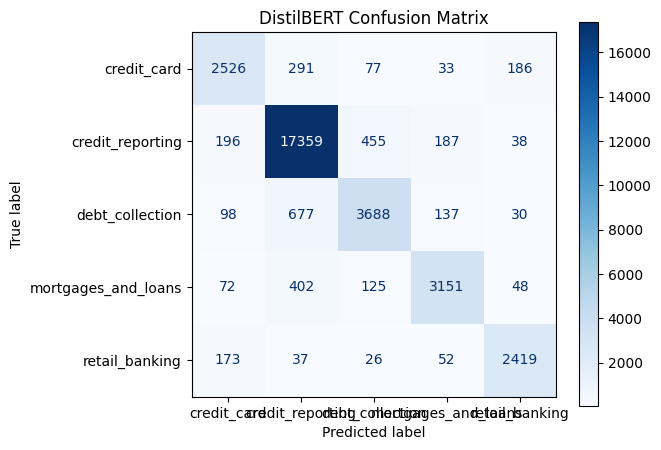

In [39]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

plt.figure(figsize=(8,6))

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("DistilBERT Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/distilbert_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [40]:
report = classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    "/kaggle/working/distilbert_classification_report.csv"
)

report_df

,precision,recall,f1-score,support
credit_card,0.824144,0.811436,0.817740,3113.000000
credit_reporting,0.925024,0.951961,0.938299,18235.000000
debt_collection,0.843743,0.796544,0.819465,4630.000000
mortgages_and_loans,0.885112,0.829647,0.856483,3798.000000
retail_banking,0.889011,0.893609,0.891304,2707.000000
accuracy,0.897177,0.897177,0.897177,0.897177
macro avg,0.873407,0.856639,0.864658,32483.000000
weighted avg,0.896103,0.897177,0.896325,32483.000000


## 12. Save 

In [41]:
results = pd.DataFrame({
    "Model": ["DistilBERT"],
    "Accuracy": [accuracy],
    "Macro Precision": [precision],
    "Macro Recall": [recall],
    "Macro F1": [f1]
})

results.to_csv(
    "/kaggle/working/distilbert_results.csv",
    index=False
)

results

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,DistilBERT,0.897177,0.873407,0.856639,0.864658


In [ ]:
with open("/kaggle/working/distilbert_label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

In [42]:
comparison_df = pd.DataFrame({
    "Model": ["SimpleRNN", "LSTM", "GRU", "DistilBERT"],
    "Accuracy": [0.7611, 0.8821, 0.8837, 0.8972],
    "Macro Precision": [0.6027, 0.8456, 0.8470, 0.8734],
    "Macro Recall": [0.6366, 0.8488, 0.8516, 0.8566],
    "Macro F1": [0.5918, 0.8469, 0.8491, 0.8647]
})

comparison_df.to_csv("/kaggle/working/model_comparison.csv", index=False)

comparison_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,SimpleRNN,0.7611,0.6027,0.6366,0.5918
1,LSTM,0.8821,0.8456,0.8488,0.8469
2,GRU,0.8837,0.8470,0.8516,0.8491
3,DistilBERT,0.8972,0.8734,0.8566,0.8647


## 13. Export Model for Deployment


In [ ]:
# =====================================================
# Save DistilBERT model for deployment
# =====================================================
import shutil

SAVE_DIR = "/kaggle/working/distilbert_saved"

# Save model weights + config
trainer.save_model(SAVE_DIR)

# Save tokenizer alongside the model
tokenizer.save_pretrained(SAVE_DIR)

# Zip it for easy download
shutil.make_archive(
    "/kaggle/working/distilbert_saved",
    "zip",
    "/kaggle/working",
    "distilbert_saved"
)

print("Model saved to:", SAVE_DIR)
print("Zip created:  /kaggle/working/distilbert_saved.zip")
print("Download the zip from Kaggle Output panel and extract to: models/distilbert_saved/")
